# TCAM — Analisi longitudinale di metaboliti e fragilità

Pipeline completa basata su **TCAM** (Tensor Component Analysis, Mor et al. 2022, *PLoS Comp. Biol.*).

**Obiettivo:** identificare i metaboliti il cui andamento longitudinale è associato alla fragilità (Ever-frail vs Never-frail) in 609 pazienti con 4 time-point (anni 0, 2, 4, 8).

**Pipeline:** Normalizzazione → TCAM → test sui fattori → pruning → LMER → FDR → interpretazione.

In [114]:
# ── Imports & Constants ──────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind, f_oneway
from statsmodels.stats.multitest import multipletests
from sklearn.metrics import pairwise_distances
import statsmodels.formula.api as smf
from mprod import table2tensor
from mprod.dimensionality_reduction import TCAM
import warnings
warnings.filterwarnings("ignore")

# ── Paths ──
FIBS_PATH  = "/Users/filipposaccomano/Downloads/Metabolomics data Mario Negri/FIBS_Single molecule_Feb26.xlsx"
MICRO_PATH = "/Users/filipposaccomano/Downloads/Metabolomics data Mario Negri/Microbiota_Single molecule_Feb26.xlsx"

# ── Constants ──
TIMES          = [1, 2, 3, 4]
TIME_TO_YEARS  = {1: 0, 2: 2, 3: 4, 4: 8}
MAX_PCT_FLOOR  = 40.0
FRAIL_THR      = 0.25
EPS            = 1e-9
N_PERMS        = 999
SEED           = 42
META_MASTER    = ["HMDB_Metabolite","Code","Time","FI","Sesso","BMI1",
                  "C_renale","C_epatic10","AnniScuo","Subject"]
META_TCAM      = ["Code","Time","Years","Group"]

np.random.seed(SEED)
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)
sns.set_style("whitegrid")
print("✓ Setup OK")

✓ Setup OK


## A. Preparazione dati

Caricamento FIBS + Microbiota → merge → filtro NaN e floor → rinomina metaboliti → definizione gruppi frailty.

In [115]:
# ── LOAD & MERGE → df_eda ────────────────────────────────────────────

def _code(val):
    """Normalize feature ID → string."""
    if pd.isna(val): return None
    try:
        f = float(val)
        return str(int(f)) if f.is_integer() else str(f)
    except:
        return str(val).strip()

# ── FIBS ──
raw_f = pd.read_excel(FIBS_PATH, sheet_name=0, header=None)
code_row, name_row = raw_f.iloc[0], raw_f.iloc[1].astype(str)
data_f = raw_f.iloc[2:].copy().reset_index(drop=True)
data_f.columns = name_row
meta_f = [c for c in META_MASTER if c in data_f.columns]

rn_f = {}
for j, col in enumerate(data_f.columns):
    if col not in meta_f:
        c = _code(code_row.iloc[j])
        if c:
            rn_f[col] = c

df_fibs = data_f.rename(columns=rn_f)
for c in ["Code", "Time", "FI"]:
    if c in df_fibs.columns:
        df_fibs[c] = pd.to_numeric(df_fibs[c], errors="coerce")
df_fibs = df_fibs.dropna(subset=["Code", "Time"]).copy()
df_fibs["Code"] = df_fibs["Code"].astype(int)
df_fibs["Time"] = df_fibs["Time"].astype(int)
df_fibs = df_fibs[df_fibs["Time"].isin(TIMES)].copy()
fibs_met = [c for c in df_fibs.columns if c not in meta_f]

# ── MICROBIOTA ──
micro = pd.read_excel(MICRO_PATH, sheet_name=0, header=0)
micro.columns = [str(c).strip() for c in micro.columns]
micro = (micro
         .rename(columns={"TIME": "Time", "time": "Time",
                           "ID Code": "Code", "CODE": "Code", "code": "Code"})
         .drop(columns=["ID"], errors="ignore"))
micro["Code"] = pd.to_numeric(micro["Code"], errors="coerce")
micro["Time"] = pd.to_numeric(micro["Time"], errors="coerce")
micro = micro.dropna(subset=["Code", "Time"]).copy()
micro["Code"] = micro["Code"].astype(int)
micro["Time"] = micro["Time"].astype(int)
micro = micro[micro["Time"].isin(TIMES)].copy()
micro_met = [c for c in micro.columns if c not in ["Code", "Time", "Subject"]]
micro = micro.rename(columns={c: _code(c) for c in micro_met})
micro_met = [c for c in micro.columns if c not in ["Code", "Time", "Subject"]]
micro[micro_met] = micro[micro_met].apply(pd.to_numeric, errors="coerce")

# ── DEDUP & MERGE ──
dups = sorted(set(micro_met) & set(fibs_met))
if dups:
    micro = micro.drop(columns=dups)
micro_met = [c for c in micro.columns if c not in ["Code", "Time", "Subject"]]

def _compl(d):
    n = d.groupby("Code")["Time"].nunique()
    return set(n[n == len(TIMES)].index.astype(int))

common = sorted(_compl(df_fibs[["Code", "Time"]]) & _compl(micro[["Code", "Time"]]))
df = (df_fibs[df_fibs.Code.isin(common)]
      .merge(micro[micro.Code.isin(common)], on=["Code", "Time"], how="inner"))

# ── META vs METABOLITI ──
keep_meta = ["Code", "Time"]
for c in ["FI"] + META_MASTER:
    if c in df.columns and c not in keep_meta:
        keep_meta.append(c)
met_all = [c for c in df.columns if c not in keep_meta]
df[met_all] = df[met_all].apply(pd.to_numeric, errors="coerce")

# ── FILTRO NaN + FLOOR ──
nan_ok = ~df[met_all].isna().any(axis=0)
met_nn = nan_ok[nan_ok].index.tolist()
df_nn = df[keep_meta + met_nn]
fl = df_nn[met_nn].min()
pct = df_nn[met_nn].eq(fl, axis=1).mean() * 100
met_ok = pct[pct <= MAX_PCT_FLOOR].index.tolist()
df_eda = df_nn[keep_meta + met_ok].copy()
met_cols = met_ok[:]

# ── RINOMINA FIBS: codice → nome ──
c2n = {}
for j in range(len(name_row)):
    nm = str(name_row.iloc[j]).strip()
    if nm in META_MASTER:
        continue
    cv = _code(code_row.iloc[j])
    if cv:
        c2n[cv] = nm
rn = {c: c2n[c] for c in met_cols if c in c2n}
nc = pd.Series(list(rn.values())).value_counts()
for d in nc[nc > 1].index:
    for k, v in list(rn.items()):
        if v == d:
            rn[k] = k
df_eda = df_eda.rename(columns=rn)
met_cols = [rn.get(c, c) for c in met_cols]

print(f"✓ df_eda: {len(df_eda)} righe, {df_eda['Code'].nunique()} pazienti, "
      f"{len(met_cols)} metaboliti")

✓ df_eda: 2436 righe, 609 pazienti, 39 metaboliti


In [116]:
# ── GRUPPI FRAILTY + TEMPO ────────────────────────────────────────────
df_eda["FI"] = pd.to_numeric(df_eda["FI"], errors="coerce")
ever_frail = (df_eda.groupby("Code")["FI"]
              .apply(lambda s: (s >= FRAIL_THR).any()).to_dict())
df_eda["Group"] = df_eda["Code"].map(
    lambda x: "Ever-frail" if ever_frail[x] else "Never-frail")
df_eda["Years"] = df_eda["Time"].map(TIME_TO_YEARS)

# ── Sanity checks ──
grp = df_eda[["Code", "Group"]].drop_duplicates()["Group"].value_counts()
print("Gruppi:")
print(grp.to_string())
print(f"\nTimepoints: {sorted(df_eda['Time'].unique())}")
print(f"Anni reali: {sorted(df_eda['Years'].unique())}")
assert df_eda.groupby("Code")["Time"].nunique().eq(4).all(), "Non tutti hanno 4 visite!"
print("✓ Tutti i pazienti hanno esattamente 4 visite")

display(df_eda[["Code", "Time", "Years", "Group", "FI"] + met_cols[:3]].head(8))

Gruppi:
Group
Never-frail    457
Ever-frail     152

Timepoints: [1, 2, 3, 4]
Anni reali: [0, 2, 4, 8]
✓ Tutti i pazienti hanno esattamente 4 visite


,Code,Time,Years,Group,FI,Benzoic acid,3-Methylhistidine; 1-Methylhistidine; 1-methylhistidine; 3-methylhistidine;,Pyrogallol
0,9,1,0,Never-frail,0.060606,3639.20,6492.7,1.46
1,9,2,2,Never-frail,0.060606,3262.80,6380.9,3127.70
2,9,3,4,Never-frail,0.060606,996.90,6249.1,167126.80
3,9,4,8,Never-frail,0.096774,0.22,8456.9,1.46
4,11,1,0,Never-frail,0.166667,3542.00,13480.7,1269.50
5,11,2,2,Never-frail,0.196970,3240.90,14768.9,1029.90
6,11,3,4,Never-frail,0.227273,2025.30,1.6,1.46
7,11,4,8,Never-frail,0.225806,2642.20,13299.7,11210.70


## B. Normalizzazioni per TCAM

**Scelta metodologica.** Dai test comparativi (PERMANOVA + t-test su F1), il metodo più performante è risultato **log2fc**.  
Per questo, invece di confrontare metodi troppo diversi, confrontiamo **tre varianti coerenti con log2fc**.

I dati metabolomici sono **non composizionali**, quindi non usiamo CLR.

**Metodi confrontati:**

| Metodo | Descrizione | Quando è utile |
|--------|-------------|----------------|
| `log2fc` | \( \log_2(x_t/x_{baseline}) \) per soggetto (baseline = visita 1). Il floor è già presente nel dataset preprocessato. | Metodo principale; interpretabile biologicamente e robusto alle scale diverse. |
| `log2fc_robust` | `log2fc` + robust scaling per feature: \((x-\text{mediana})/\text{IQR}\). | Se ci sono outlier o distribuzioni con code pesanti. |
| `log2fc_visitcorr` | `log2fc` + sottrazione della media per visita (correzione visit-effect/drift). | Se è presente drift globale legato al timepoint. |

Per ogni metodo: `table2tensor` → `TCAM()` → scores, loadings, explained variance.

**Obiettivo del confronto:** verificare se una variante di `log2fc` migliora ulteriormente separazione tra gruppi e stabilità dei fattori, mantenendo interpretabilità biologica.

In [117]:
# ── NORMALIZZAZIONI + FIT TCAM ───────────────────────────────────────

def _baseline_sub(df_in, met, baseline_t=1):
    """Vectorized baseline subtraction per soggetto."""
    bl = (df_in[df_in["Time"] == baseline_t]
          .set_index("Code")[met])
    return df_in[met].values - bl.loc[df_in["Code"].values].values



def norm_log2fc(df_in, met, baseline_t=1):
    """Log₂ fold-change da baseline.
    I dati hanno già il floor impostato nel preprocessing."""
    X = df_in[met].values.astype(float)
    # Il floor è già stato applicato nel preprocessing, semplicemente trasformiamo in log₂
    X = np.log2(X)
    # Sottrai baseline (in scala log = log-ratio)
    bl = pd.DataFrame(X[df_in["Time"].values == baseline_t],
                      columns=met,
                      index=df_in.loc[df_in["Time"] == baseline_t, "Code"].values)
    X = X - bl.loc[df_in["Code"].values].values
    out = df_in[META_TCAM].reset_index(drop=True).copy()
    for i, c in enumerate(met):
        out[c] = X[:, i]
    return out


def norm_log2fc_visit_refNF(df_in, met, baseline_t=1):
    """
    log2fc + drift correction stimata sui Never-frail.
    Corregge lo shift di visita comune senza usare Ever-frail per stimare il drift.
    """
    out = norm_log2fc(df_in, met, baseline_t=baseline_t)
    out_corr = out.copy()

    ref_mask_global = out_corr["Group"] == "Never-frail"
    for y in sorted(out_corr["Years"].dropna().unique()):
        mask_y = out_corr["Years"] == y
        ref_mask = mask_y & ref_mask_global

        # fallback se per qualche motivo non ci sono NF in una visita
        if ref_mask.sum() == 0:
            ref_mean = out_corr.loc[mask_y, met].mean(axis=0)
        else:
            ref_mean = out_corr.loc[ref_mask, met].mean(axis=0)

        out_corr.loc[mask_y, met] = out_corr.loc[mask_y, met] - ref_mean.values

    return out_corr

def norm_log2fc_visit_median(df_in, met, baseline_t=1):
    """log2fc + rimozione drift per visita usando la mediana (robusta)."""
    out = norm_log2fc(df_in, met, baseline_t=baseline_t)
    out_corr = out.copy()
    for y in sorted(out_corr["Years"].dropna().unique()):
        mask = out_corr["Years"] == y
        visit_med = out_corr.loc[mask, met].median(axis=0)
        out_corr.loc[mask, met] = out_corr.loc[mask, met] - visit_med.values
    return out_corr

def _drop_bad(df_in, meta, feat):
    """Rimuovi feature con NaN o varianza zero dopo normalizzazione."""
    ok = [c for c in feat if not df_in[c].isna().any() and df_in[c].std() > 0]
    return df_in[meta + ok].copy(), ok

def fit_tcam(df_norm, met_feat):
    """Fit TCAM: table → tensor → scores, loadings, explained variance."""
    tab = df_norm.set_index(["Code", "Time"])[met_feat].sort_index()
    tensor, map_subj, map_time = table2tensor(tab)
    tca = TCAM()
    scores = tca.fit_transform(tensor)
    inv_subj = {v: k for k, v in map_subj.items()}
    scores_df = pd.DataFrame(
        scores,
        index=[inv_subj[i] for i in range(scores.shape[0])],
        columns=[f"F{i+1}" for i in range(scores.shape[1])])
    scores_df.index.name = "Code"
    scores_df = scores_df.reset_index()
    grp = df_norm[["Code", "Group"]].drop_duplicates()
    scores_df = scores_df.merge(grp, on="Code", how="left")
    ev = pd.Series(tca.explained_variance_ratio_,
                   index=[f"F{i+1}" for i in range(len(tca.explained_variance_ratio_))])
    loadings = tca.mode2_loadings  # shape (n_features, n_components)
    return {"scores": scores_df, "ev": ev, "loadings": loadings,
            "tca": tca, "tensor": tensor, "features": met_feat,
            "map_subj": map_subj, "map_time": map_time}

# ── Fit metodi aggiornati ──
methods = {}
for name, fn in [
    ("log2fc_visit_refNF", norm_log2fc_visit_refNF),
    ("log2fc_visit_median", norm_log2fc_visit_median),
]:
    df_n = fn(df_eda.copy(), met_cols)
    df_n, feat = _drop_bad(df_n, META_TCAM, met_cols)
    res = fit_tcam(df_n, feat)
    res["df_norm"] = df_n
    methods[name] = res
    print(f"  {name}: {len(feat)} features, tensor {res['tensor'].shape}, "
          f"EV top-3 = {res['ev'].iloc[:3].values.round(4)}")

print("\n✓ TCAM fit completato per i metodi aggiornati")


  log2fc_visit_refNF: 39 features, tensor (609, 39, 4), EV top-3 = [0.0846 0.0618 0.0475]
  log2fc_visit_median: 39 features, tensor (609, 39, 4), EV top-3 = [0.0846 0.0618 0.0475]

✓ TCAM fit completato per i metodi aggiornati


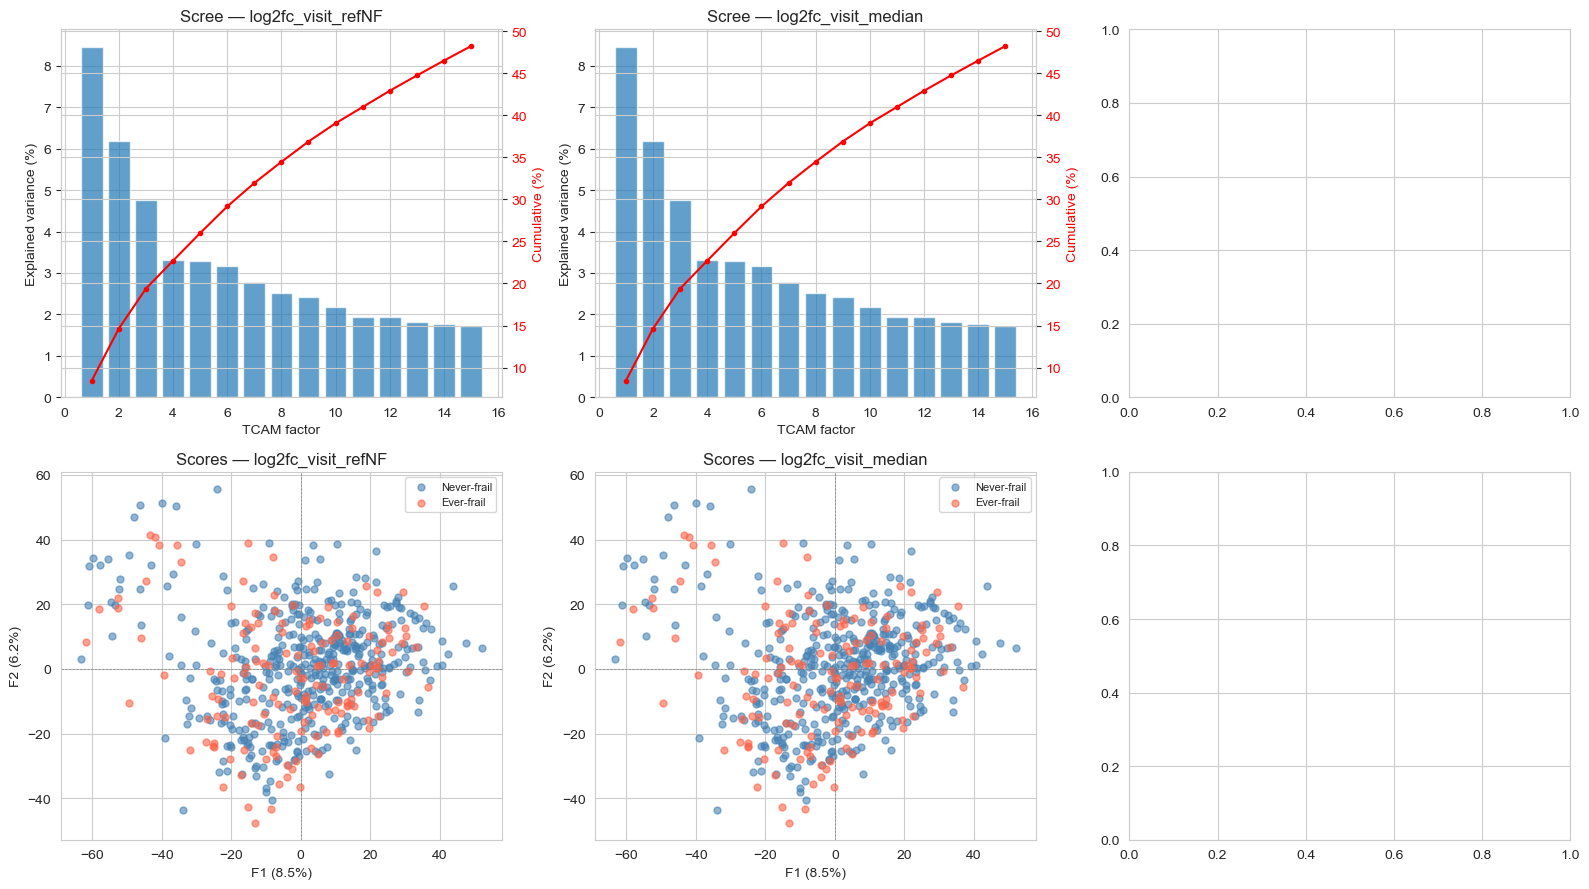

In [118]:
# ── CONFRONTO VISUALE ────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
method_names = list(methods.keys())

# Riga 1: Scree plots
for i, name in enumerate(method_names):
    ax = axes[0, i]
    ev = methods[name]["ev"]
    n_show = min(15, len(ev))
    ax.bar(range(1, n_show + 1), ev.values[:n_show] * 100, alpha=0.7)
    ax.set_xlabel("TCAM factor")
    ax.set_ylabel("Explained variance (%)")
    ax.set_title(f"Scree — {name}")
    cum = ev.cumsum()
    ax2 = ax.twinx()
    ax2.plot(range(1, n_show + 1), cum.values[:n_show] * 100,
             "r-o", markersize=3)
    ax2.set_ylabel("Cumulative (%)", color="r")
    ax2.tick_params(axis="y", labelcolor="r")

# Riga 2: Scatter F1 vs F2
colors = {"Never-frail": "steelblue", "Ever-frail": "tomato"}
for i, name in enumerate(method_names):
    ax = axes[1, i]
    sc = methods[name]["scores"]
    ev = methods[name]["ev"]
    for grp in ["Never-frail", "Ever-frail"]:
        sub = sc[sc["Group"] == grp]
        ax.scatter(sub["F1"], sub["F2"], s=25, alpha=0.6,
                   label=grp, color=colors[grp])
    ax.axhline(0, ls="--", lw=0.5, c="gray")
    ax.axvline(0, ls="--", lw=0.5, c="gray")
    ax.set_xlabel(f"F1 ({ev['F1']*100:.1f}%)")
    ax.set_ylabel(f"F2 ({ev['F2']*100:.1f}%)")
    ax.set_title(f"Scores — {name}")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## C. Test statistici sui fattori TCAM

**PERMANOVA** (Permutational ANOVA) sui TCAM scores per testare la separazione tra gruppi (implementazione custom basata su distanze Euclidee, come nel paper — skbio non è necessario).

**t-test** per singolo fattore: identifica quali fattori separano i due gruppi.

**Selezione fattori:** si usano solo i fattori con explained variance > 2.5% (criterio `min_var` del paper, `get_truncated_factors`).

In [119]:
# ── PERMANOVA + T-TEST + SELEZIONE METODO ────────────────────────────

def permanova(scores_arr, labels, n_perms=999):
    """PERMANOVA custom su distanze Euclidee (come nel paper Sailani2020).
    Testa se i centroidi dei gruppi differiscono significativamente."""
    labels = np.asarray(labels)
    unique_g = np.unique(labels)
    n, k = len(labels), len(unique_g)
    D2 = pairwise_distances(scores_arr, metric="euclidean") ** 2

    def _pseudo_f(lab):
        ss_t = D2.sum() / (2 * n)
        ss_w = sum(D2[np.ix_(lab == g, lab == g)].sum() / (2 * (lab == g).sum())
                   for g in unique_g if (lab == g).sum() > 1)
        ss_b = ss_t - ss_w
        return (ss_b / max(k - 1, 1)) / (ss_w / max(n - k, 1))

    f_obs = _pseudo_f(labels)
    count = sum(1 for _ in range(n_perms)
                if _pseudo_f(np.random.permutation(labels)) >= f_obs)
    return f_obs, (count + 1) / (n_perms + 1)

def select_factors(tca_obj, threshold=0.025):
    """Seleziona fattori con explained variance > threshold (paper: 2.5%)."""
    ev = tca_obj.explained_variance_ratio_
    n = int(np.sum(ev > threshold))
    return max(n, 1)

# ── Test per ogni metodo ──
comparison = []
for name, res in methods.items():
    sc = res["scores"]
    ev = res["ev"]
    tca = res["tca"]
    n_fac = select_factors(tca, threshold=0.025)

    # PERMANOVA sui primi n_fac fattori
    fac_cols = [f"F{i+1}" for i in range(n_fac)]
    labels = sc["Group"].values
    f_stat, p_perm = permanova(sc[fac_cols].values, labels, n_perms=N_PERMS)

    # t-test su F1
    f1_ef = sc.loc[sc["Group"] == "Ever-frail", "F1"].values
    f1_nf = sc.loc[sc["Group"] == "Never-frail", "F1"].values
    t_stat, p_t = ttest_ind(f1_ef, f1_nf, equal_var=False)

    comparison.append({
        "method": name,
        "n_factors_selected": n_fac,
        "EV_F1_pct": ev["F1"] * 100,
        "EV_top_n_pct": ev.iloc[:n_fac].sum() * 100,
        "PERMANOVA_F": f_stat,
        "PERMANOVA_p": p_perm,
        "ttest_F1_t": t_stat,
        "ttest_F1_p": p_t,
    })

comp_df = pd.DataFrame(comparison).sort_values("PERMANOVA_p")
display(comp_df)

# ── Selezione metodo migliore ──
best_method = comp_df.iloc[0]["method"]
print(f"\n✓ Metodo migliore (PERMANOVA p più bassa): {best_method}")

,method,n_factors_selected,EV_F1_pct,EV_top_n_pct,PERMANOVA_F,PERMANOVA_p,ttest_F1_t,ttest_F1_p
0,log2fc_visit_refNF,8,8.457776,34.463751,6.853731,0.001,-1.799582,0.073131
1,log2fc_visit_median,8,8.457776,34.463751,6.853731,0.001,-1.799582,0.073131



✓ Metodo migliore (PERMANOVA p più bassa): log2fc_visit_refNF


## D. Analisi dettagliata — Metodo migliore

Boxplot dei fattori significativi, t-test per ogni fattore con FDR, e distribuzione degli scores.

Metodo: log2fc_visit_refNF
Fattori selezionati: 8 (['F1', 'F2', 'F3', 'F4', 'F5', 'F6', 'F7', 'F8'])
EV cumulata: 34.5%



,Factor,t_stat,p_value,mean_EF,mean_NF,EV_pct,q_value
0,F1,-1.799582,0.073131,-2.586857,0.860399,8.457776,0.117010
1,F2,-1.647919,0.100687,-2.089314,0.694914,6.182135,0.134249
2,F3,-3.425120,0.000713,-3.556846,1.183021,4.750404,0.001900
3,F4,-4.780322,0.000003,-4.372178,1.454204,3.315635,0.000025
4,F5,-1.879055,0.061312,-1.608058,0.534846,3.282064,0.117010
5,F6,0.575727,0.565261,0.475897,-0.158285,3.168031,0.565261
6,F7,1.150789,0.250972,0.980315,-0.326056,2.786160,0.286825
7,F8,-3.651149,0.000321,-2.922746,0.972117,2.521547,0.001283


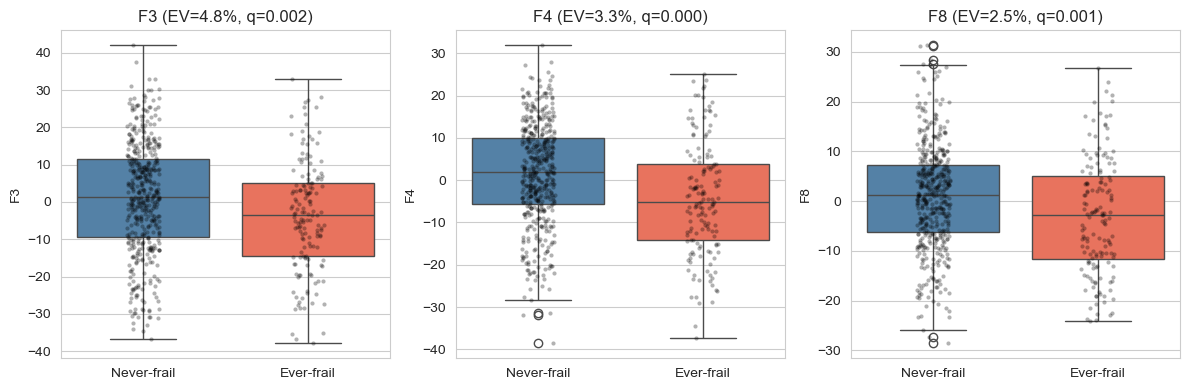

In [120]:
# ── ANALISI DETTAGLIATA DEL METODO MIGLIORE ──────────────────────────
best = methods[best_method]
sc = best["scores"]
ev = best["ev"]
tca = best["tca"]
n_fac = select_factors(tca, threshold=0.025)
fac_cols = [f"F{i+1}" for i in range(n_fac)]

print(f"Metodo: {best_method}")
print(f"Fattori selezionati: {n_fac} ({fac_cols})")
print(f"EV cumulata: {ev.iloc[:n_fac].sum()*100:.1f}%\n")

# ── t-test per ogni fattore selezionato con FDR ──
fac_tests = []
for f in fac_cols:
    ef = sc.loc[sc["Group"] == "Ever-frail", f].values
    nf = sc.loc[sc["Group"] == "Never-frail", f].values
    t, p = ttest_ind(ef, nf, equal_var=False)
    fac_tests.append({"Factor": f, "t_stat": t, "p_value": p,
                      "mean_EF": ef.mean(), "mean_NF": nf.mean(),
                      "EV_pct": ev[f] * 100})

fac_df = pd.DataFrame(fac_tests)
if len(fac_df) > 1:
    _, fac_df["q_value"], _, _ = multipletests(fac_df["p_value"], method="fdr_bh")
else:
    fac_df["q_value"] = fac_df["p_value"]
display(fac_df)

# ── Boxplot fattori significativi (q < 0.1) ──
sig_facs = fac_df[fac_df["q_value"] < 0.1]["Factor"].tolist()
if not sig_facs:
    sig_facs = fac_cols[:min(3, len(fac_cols))]  # mostra almeno i top-3
    print("Nessun fattore con q < 0.1 — mostro i primi 3")

n_plots = len(sig_facs)
fig, axes = plt.subplots(1, n_plots, figsize=(4 * n_plots, 4))
if n_plots == 1:
    axes = [axes]
for ax, f in zip(axes, sig_facs):
    sns.boxplot(data=sc, x="Group", y=f, ax=ax, palette=colors)
    sns.stripplot(data=sc, x="Group", y=f, ax=ax, alpha=0.3, size=3, color="black")
    p = fac_df.loc[fac_df["Factor"] == f, "q_value"].values[0]
    ax.set_title(f"{f} (EV={ev[f]*100:.1f}%, q={p:.3f})")
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

## E. Pruning delle feature

**Strategia di pruning basata sui loadings** (Mor et al. 2022, analisi Sailani2020):

1. Identifica i fattori significativi (q < 0.1, oppure top-2)
2. Per ogni feature, calcola il prodotto dei loadings sui fattori significativi
3. Filtra le feature nel quartile superiore (75° percentile) del |prodotto|
4. Seleziona le top/bottom N feature per ciascun fattore
5. L'unione è il set finale di metaboliti "pruned"

Fattori usati per pruning: ['F3', 'F4', 'F8']
Feature prima del pruning: 39
Feature selezionate (pruned): 39


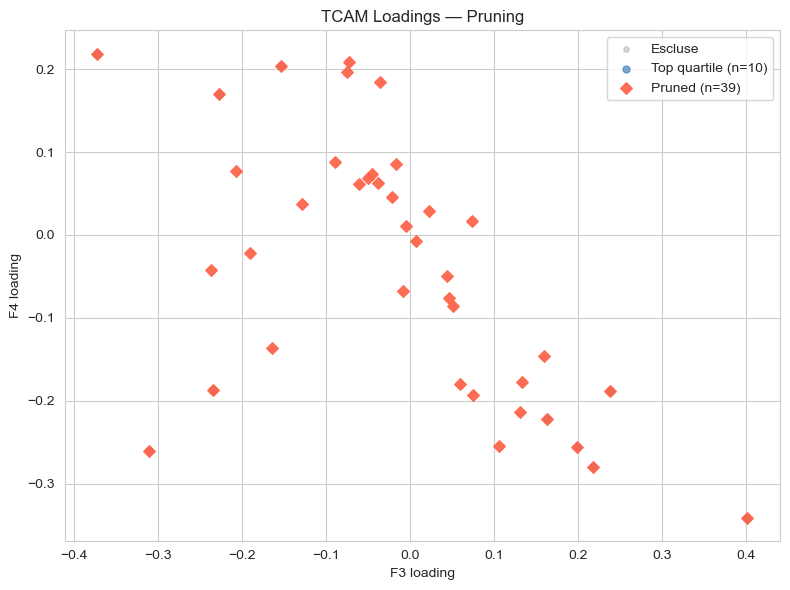


Metaboliti selezionati (39):
  • Benzoic acid
  • 3-Methylhistidine; 1-Methylhistidine; 1-methylhistidine; 3-methylhistidine;
  • Pyrogallol
  • 6-Hydroxypseudooxynicotine
  • 1-(2,6-Dihydroxy-4-methoxyphenyl)-3-phenyl-1-propanone
  • Carnosine
  • Caffeine
  • Daidzein
  • Enterodiol
  • Pinoresinol
  • Phloretin
  • Resveratrol
  • Secoisolariciresinol
  • Uric acid
  • Resveratrol-O-glucuronide
  • 2-Hydroxycinnamic acid
  • Hippuric acid
  • myo-Inositol
  • Saccharin
  • 5-acetylamino-6-amino-3-methyluracil ((AAMU)
  • Arachidonic acid
  • Dihomo-gamma-linolenic acid (DGLA; cis-20:3n-6)
  • Isorhamnetin
  • 70569
  • 86252
  • 88195
  • 88933
  • 103418
  • 103971
  • 107237
  ... e altri 9


In [121]:
# ── PRUNING BASATO SUI LOADINGS ──────────────────────────────────────
loadings = best["loadings"]       # (n_features, n_components)
features = best["features"]

# Fattori per il pruning: quelli significativi, o almeno i primi 2
prune_facs = sig_facs if len(sig_facs) >= 1 else fac_cols[:2]
prune_idx = [int(f.replace("F", "")) - 1 for f in prune_facs]
print(f"Fattori usati per pruning: {prune_facs}")

# Loadings sui fattori selezionati
L = loadings[:, prune_idx]

# Prodotto dei loadings (se >1 fattore, altrimenti valore assoluto)
if L.shape[1] >= 2:
    product = np.abs(L[:, 0] * L[:, 1])
else:
    product = np.abs(L[:, 0])

# Soglia: 75° percentile
q75 = np.quantile(product, 0.75)
mask_q = product >= q75

# Top/bottom 20 per ogni fattore (tra quelli sopra soglia)
TOP_N = 20
selected = set()
for j in range(L.shape[1]):
    vals = L[:, j].copy()
    vals[~mask_q] = 0
    idx_sorted = np.argsort(vals)
    selected.update(idx_sorted[:TOP_N])
    selected.update(idx_sorted[-TOP_N:])

pruned_idx = sorted(selected)
pruned_features = [features[i] for i in pruned_idx]
print(f"Feature prima del pruning: {len(features)}")
print(f"Feature selezionate (pruned): {len(pruned_features)}")

# ── Visualizzazione loadings ──
fig, ax = plt.subplots(figsize=(8, 6))
if L.shape[1] >= 2:
    ax.scatter(L[~mask_q, 0], L[~mask_q, 1], s=15, alpha=0.3,
               c="gray", label="Escluse")
    ax.scatter(L[mask_q, 0], L[mask_q, 1], s=25, alpha=0.7,
               c="steelblue", label=f"Top quartile (n={mask_q.sum()})")
    sel_mask = np.zeros(len(features), dtype=bool)
    sel_mask[pruned_idx] = True
    ax.scatter(L[sel_mask, 0], L[sel_mask, 1], s=35, alpha=0.9,
               c="tomato", marker="D", label=f"Pruned (n={len(pruned_features)})")
    ax.set_xlabel(f"{prune_facs[0]} loading")
    ax.set_ylabel(f"{prune_facs[1]} loading")
else:
    ax.bar(range(len(pruned_idx)), L[pruned_idx, 0])
    ax.set_xlabel("Feature index")
    ax.set_ylabel(f"{prune_facs[0]} loading")
ax.set_title("TCAM Loadings — Pruning")
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nMetaboliti selezionati ({len(pruned_features)}):")
for m in pruned_features[:30]:
    print(f"  • {m}")
if len(pruned_features) > 30:
    print(f"  ... e altri {len(pruned_features)-30}")

## F. Drift / Visit Effect

Verifica se esiste un **effetto visita globale** (drift sistematico nel tempo):
- Media dei metaboliti normalizzati per timepoint, indipendentemente dal gruppo
- Se il drift è forte, i fattori TCAM potrebbero catturare la variazione temporale globale piuttosto che la differenza tra gruppi
- Confronto: TCAM con e senza rimozione dell'effetto visita (sottrazione media per timepoint)

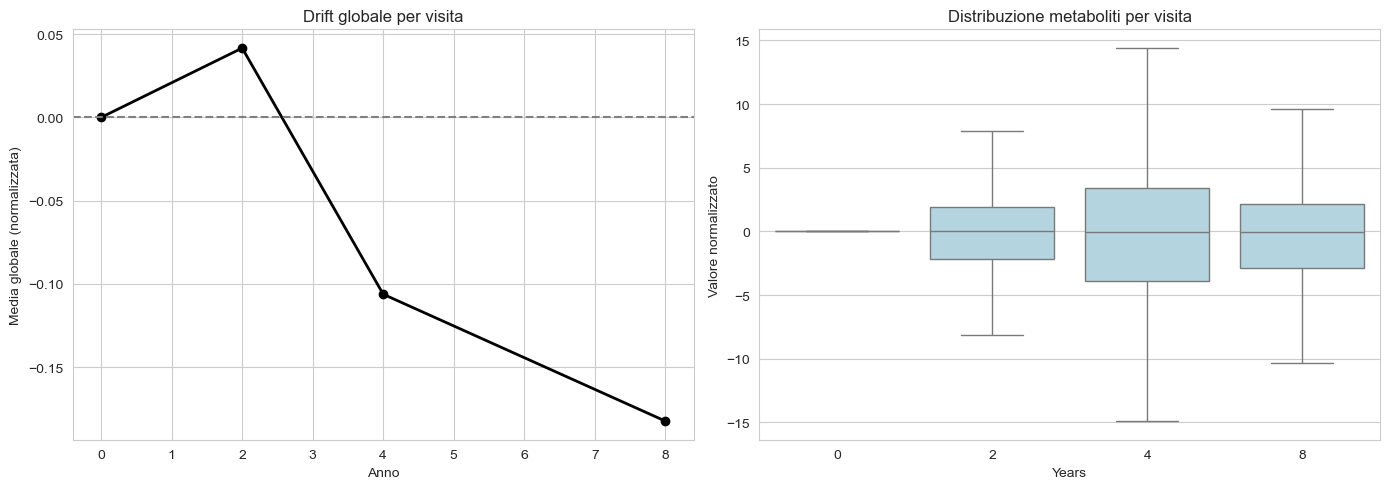

Range drift medio globale: 0.2241
→ Drift presente. Provo versione con correzione visit-effect.

Con visit-correction:
  Fattori selezionati: 8
  PERMANOVA F=6.854, p=0.0010


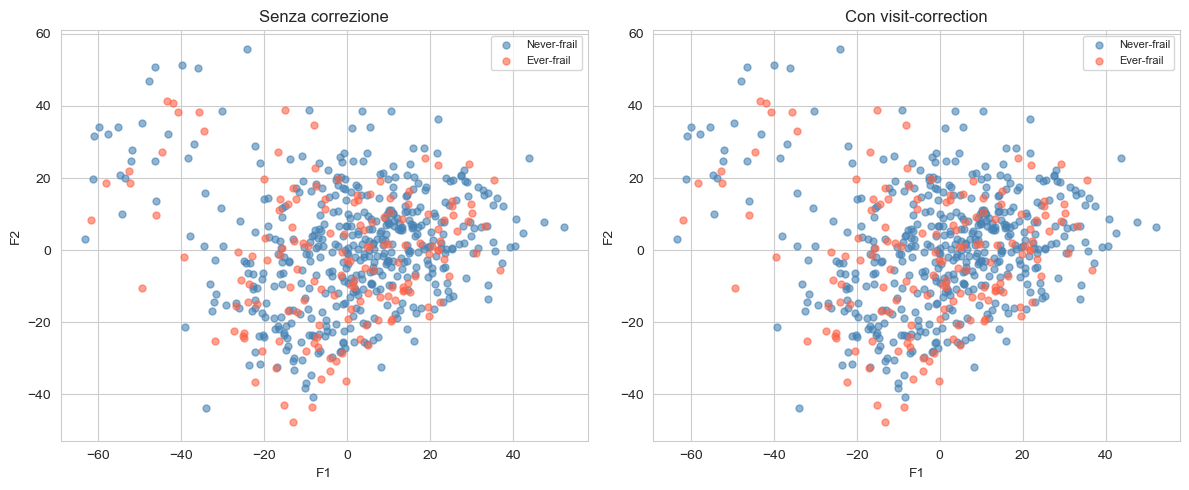

In [122]:
# ── DRIFT / VISIT EFFECT ─────────────────────────────────────────────
df_best = best["df_norm"]
feat_best = best["features"]

# Media dei metaboliti normalizzati per timepoint (tutti i soggetti)
visit_means = df_best.groupby("Years")[feat_best].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: media globale dei metaboliti per visita
global_mean = visit_means.mean(axis=1)
axes[0].plot(global_mean.index, global_mean.values, "ko-", linewidth=2)
axes[0].set_xlabel("Anno")
axes[0].set_ylabel("Media globale (normalizzata)")
axes[0].set_title("Drift globale per visita")
axes[0].axhline(0, ls="--", c="gray")

# Plot 2: distribuzione per visita (boxplot di tutte le feature)
melt = df_best[["Years"] + feat_best].melt(id_vars="Years",
                                            var_name="Metabolite",
                                            value_name="Value")
sns.boxplot(data=melt, x="Years", y="Value", ax=axes[1],
            showfliers=False, color="lightblue")
axes[1].set_title("Distribuzione metaboliti per visita")
axes[1].set_ylabel("Valore normalizzato")
plt.tight_layout()
plt.show()

# ── Valutazione drift ──
drift_range = global_mean.max() - global_mean.min()
print(f"Range drift medio globale: {drift_range:.4f}")
if drift_range < 0.1:
    print("→ Drift trascurabile. Non è necessaria correzione.")
    drift_correction_needed = False
else:
    print("→ Drift presente. Provo versione con correzione visit-effect.")
    drift_correction_needed = True

# ── Se drift presente: TCAM con visit-effect removal ──
if drift_correction_needed:
    # Sottrai la media per timepoint (rimuove l'effetto visita globale)
    df_corrected = df_best.copy()
    for t in df_corrected["Years"].unique():
        mask = df_corrected["Years"] == t
        t_mean = df_corrected.loc[mask, feat_best].mean()
        df_corrected.loc[mask, feat_best] -= t_mean

    res_corr = fit_tcam(df_corrected, feat_best)
    n_fac_corr = select_factors(res_corr["tca"], threshold=0.025)
    fac_cols_corr = [f"F{i+1}" for i in range(n_fac_corr)]

    # PERMANOVA
    f_c, p_c = permanova(res_corr["scores"][fac_cols_corr].values,
                          res_corr["scores"]["Group"].values, n_perms=N_PERMS)

    print(f"\nCon visit-correction:")
    print(f"  Fattori selezionati: {n_fac_corr}")
    print(f"  PERMANOVA F={f_c:.3f}, p={p_c:.4f}")

    # Confronto scatter
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, (title, sc_data) in zip(axes,
        [("Senza correzione", best["scores"]),
         ("Con visit-correction", res_corr["scores"])]):
        for grp in ["Never-frail", "Ever-frail"]:
            sub = sc_data[sc_data["Group"] == grp]
            ax.scatter(sub["F1"], sub["F2"], s=25, alpha=0.6,
                       label=grp, color=colors[grp])
        ax.set_title(title)
        ax.set_xlabel("F1"); ax.set_ylabel("F2")
        ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    print("Nessuna correzione necessaria.")

## G. LMER — Linear Mixed Effects Models

**Modello per ogni metabolita pruned:**

$$\text{metabolita} \sim \text{Years} \times \text{Group} + (1 \mid \text{Subject})$$

- **Fixed effects:** tempo (Years), gruppo (Group), interazione
- **Random effects:** intercetta per soggetto — cattura la correlazione longitudinale
- **Wald test** per i coefficienti (approssimazione Python del Type II ANOVA usato in R nel paper)
- **FDR (Benjamini-Hochberg)** sui p-value del gruppo e dell'interazione

Il modello viene fittato sui dati **raw** (non normalizzati), z-scored per stabilità numerica, seguendo la logica del paper dove l'LMER viene applicato ai dati originali.

In [123]:
# ── LMER SUI METABOLITI PRUNED ────────────────────────────────────────

# Prepara dati per LMER (dati raw, z-scored per stabilità numerica)
df_lmer = df_eda[["Code", "Time", "Years", "Group"] + pruned_features].copy()
df_lmer["Group"] = pd.Categorical(df_lmer["Group"],
                                   categories=["Never-frail", "Ever-frail"])

lmer_results = []
n_total = len(pruned_features)
for i, met in enumerate(pruned_features):
    y = df_lmer[met].astype(float)
    mu, sd = y.mean(), y.std()
    if sd < EPS:
        continue
    df_lmer["y"] = (y - mu) / sd

    try:
        model = smf.mixedlm("y ~ Years * Group", data=df_lmer,
                             groups=df_lmer["Code"])
        res = model.fit(reml=True, method="lbfgs")
        lmer_results.append({
            "metabolite": met,
            "beta_group": res.params.get("Group[T.Ever-frail]", np.nan),
            "beta_interaction": res.params.get("Years:Group[T.Ever-frail]", np.nan),
            "beta_years": res.params.get("Years", np.nan),
            "p_group": res.pvalues.get("Group[T.Ever-frail]", np.nan),
            "p_interaction": res.pvalues.get("Years:Group[T.Ever-frail]", np.nan),
            "p_years": res.pvalues.get("Years", np.nan),
        })
    except Exception as e:
        lmer_results.append({
            "metabolite": met,
            "beta_group": np.nan, "beta_interaction": np.nan,
            "beta_years": np.nan, "p_group": np.nan,
            "p_interaction": np.nan, "p_years": np.nan,
        })

    if (i + 1) % 20 == 0:
        print(f"  LMER: {i+1}/{n_total} completati...")

lmer_df = pd.DataFrame(lmer_results)

# ── FDR a due stadi (come nel paper) ──
# Stage 1: FDR su tutti i metaboliti pruned
for col in ["p_group", "p_interaction", "p_years"]:
    pvals = lmer_df[col].fillna(1).values
    _, q, _, _ = multipletests(pvals, method="fdr_bh")
    lmer_df[f"q_{col.replace('p_', '')}"] = q

# Stage 2: ri-FDR solo sui metaboliti con variazione reale (p < 1)
# (i metaboliti con troppi floor hanno tutti p=1 e non devono penalizzare la FDR)
active_mask = (lmer_df["p_group"] < 1) | (lmer_df["p_interaction"] < 1)
lmer_active = lmer_df[active_mask].copy()
n_active = len(lmer_active)

for col in ["p_group", "p_interaction", "p_years"]:
    pvals = lmer_active[col].fillna(1).values
    _, q, _, _ = multipletests(pvals, method="fdr_bh")
    lmer_active[f"q2_{col.replace('p_', '')}"] = q

print(f"\n✓ LMER completato: {len(lmer_df)} metaboliti testati, "
      f"{n_active} con variazione reale")
print(f"\n  FDR Stage 1 (tutti {len(lmer_df)} metaboliti):")
print(f"    q_group < 0.1: {(lmer_df['q_group'] < 0.1).sum()}")
print(f"    q_interaction < 0.1: {(lmer_df['q_interaction'] < 0.1).sum()}")
print(f"\n  FDR Stage 2 (solo {n_active} metaboliti attivi — ri-FDR):")
print(f"    q2_group < 0.1: {(lmer_active['q2_group'] < 0.1).sum()}")
print(f"    q2_interaction < 0.1: {(lmer_active['q2_interaction'] < 0.1).sum()}")

display(lmer_active.sort_values("q2_interaction").head(15))

  LMER: 20/39 completati...

✓ LMER completato: 39 metaboliti testati, 39 con variazione reale

  FDR Stage 1 (tutti 39 metaboliti):
    q_group < 0.1: 2
    q_interaction < 0.1: 13

  FDR Stage 2 (solo 39 metaboliti attivi — ri-FDR):
    q2_group < 0.1: 2
    q2_interaction < 0.1: 13


,metabolite,beta_group,beta_interaction,beta_years,p_group,p_interaction,p_years,q_group,q_interaction,q_years,q2_group,q2_interaction,q2_years
31,121512,0.000000,-0.081752,0.056114,1.000000,2.457511e-07,1.334746e-12,1.000000,0.000010,2.891949e-12,1.000000,0.000010,2.891949e-12
14,Resveratrol-O-glucuronide,0.232414,-0.061974,0.107413,0.003177,6.474196e-06,3.464171e-55,0.061943,0.000126,4.503423e-54,0.061943,0.000126,4.503423e-54
13,Uric acid,0.000000,-0.066700,0.085621,1.000000,2.661483e-05,3.701798e-27,1.000000,0.000346,1.604113e-26,1.000000,0.000346,1.604113e-26
25,88195,0.000000,-0.063610,0.020142,1.000000,5.473112e-05,1.055474e-02,1.000000,0.000534,1.247378e-02,1.000000,0.000534,1.247378e-02
36,133960,0.000000,-0.059315,0.070511,1.000000,1.792249e-04,4.882180e-19,1.000000,0.001398,1.360036e-18,1.000000,0.001398,1.360036e-18
35,131646,0.000000,0.050964,0.045864,1.000000,1.339798e-03,7.586819e-09,1.000000,0.008709,1.344936e-08,1.000000,0.008709,1.344936e-08
15,2-Hydroxycinnamic acid,0.000000,-0.049686,0.000155,1.000000,1.661914e-03,9.843304e-01,1.000000,0.009259,9.843304e-01,1.000000,0.009259,9.843304e-01
18,Saccharin,0.000000,0.048292,-0.070768,1.000000,2.352670e-03,4.580435e-19,1.000000,0.011469,1.360036e-18,1.000000,0.011469,1.360036e-18
37,96893,-0.269919,0.043110,-0.100277,0.000131,3.294762e-03,1.283549e-42,0.005109,0.014277,1.001168e-41,0.005109,0.014277,1.001168e-41
17,myo-Inositol,0.000000,-0.040767,0.032958,1.000000,1.026346e-02,3.270670e-05,1.000000,0.040028,5.314838e-05,1.000000,0.040028,5.314838e-05


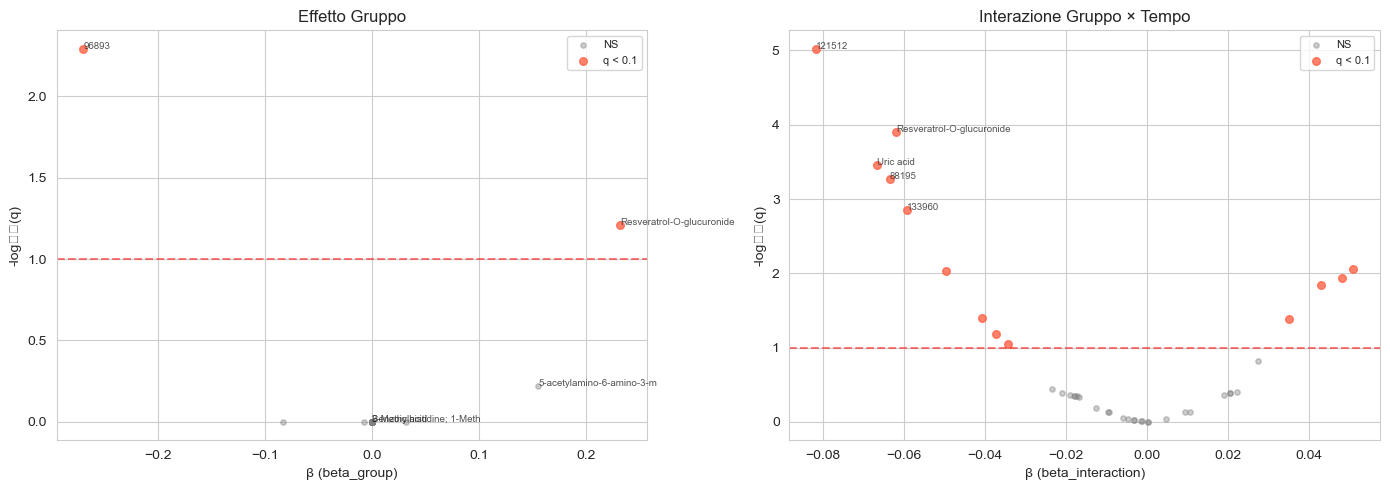

Top 10 metaboliti — effetto gruppo (ri-FDR):


,metabolite,beta_group,p_group,q2_group
0,96893,-0.269919,0.000131,0.005109
1,Resveratrol-O-glucuronide,0.232414,0.003177,0.061943
2,5-acetylamino-6-amino-3-methyluracil ((AAMU),0.155588,0.046550,0.605147
3,Benzoic acid,0.000000,1.000000,1.000000
4,3-Methylhistidine; 1-Methylhistidine; 1-methyl...,0.000000,1.000000,1.000000
5,Pyrogallol,0.000000,1.000000,1.000000
6,6-Hydroxypseudooxynicotine,0.000000,1.000000,1.000000
7,"1-(2,6-Dihydroxy-4-methoxyphenyl)-3-phenyl-1-p...",0.000000,1.000000,1.000000
8,Carnosine,0.000000,1.000000,1.000000
9,Caffeine,0.000000,1.000000,1.000000



Top 10 metaboliti — interazione gruppo × tempo (ri-FDR):


,metabolite,beta_interaction,p_interaction,q2_interaction
0,121512,-0.081752,2.457511e-07,0.000010
1,Resveratrol-O-glucuronide,-0.061974,6.474196e-06,0.000126
2,Uric acid,-0.066700,2.661483e-05,0.000346
3,88195,-0.063610,5.473112e-05,0.000534
4,133960,-0.059315,1.792249e-04,0.001398
5,131646,0.050964,1.339798e-03,0.008709
6,2-Hydroxycinnamic acid,-0.049686,1.661914e-03,0.009259
7,Saccharin,0.048292,2.352670e-03,0.011469
8,96893,0.043110,3.294762e-03,0.014277
9,myo-Inositol,-0.040767,1.026346e-02,0.040028


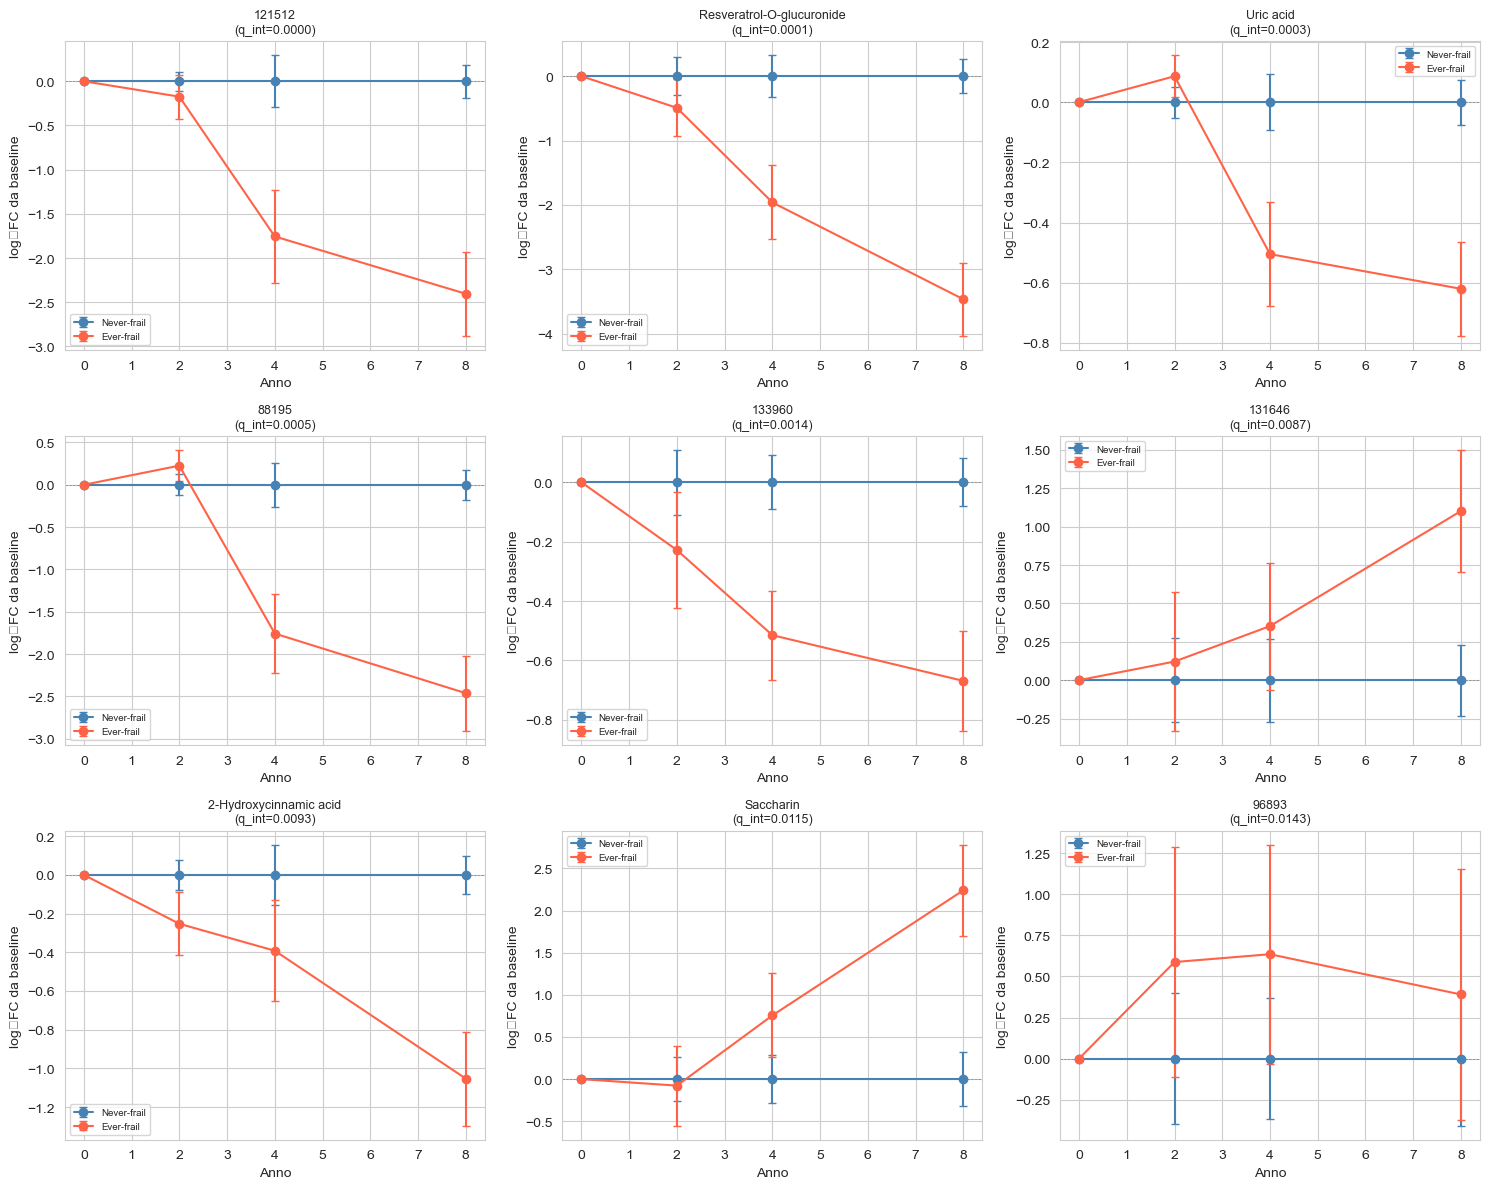

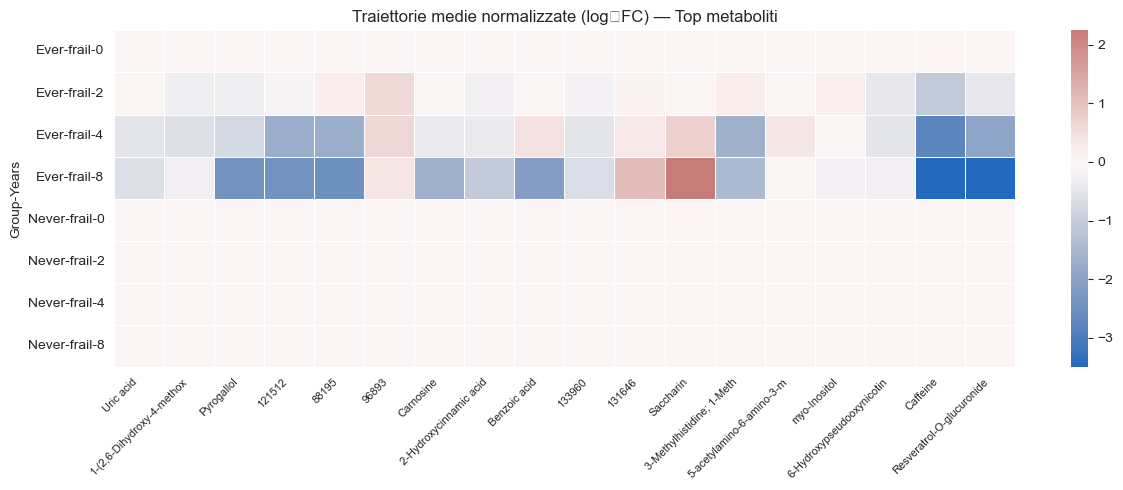

In [124]:
# ── VISUALIZZAZIONE RISULTATI LMER ────────────────────────────────────

# Volcano plot: beta vs -log10(q)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (beta_col, q_col, title) in zip(axes, [
    ("beta_group", "q2_group", "Effetto Gruppo"),
    ("beta_interaction", "q2_interaction", "Interazione Gruppo × Tempo")
]):
    valid = lmer_active.dropna(subset=[beta_col, q_col])
    x = valid[beta_col].values
    y = -np.log10(valid[q_col].values + 1e-300)
    sig = valid[q_col] < 0.1
    ax.scatter(x[~sig], y[~sig], s=15, alpha=0.4, c="gray", label="NS")
    ax.scatter(x[sig], y[sig], s=30, alpha=0.8, c="tomato", label="q < 0.1")
    ax.axhline(-np.log10(0.1), ls="--", c="red", alpha=0.5)
    ax.set_xlabel(f"β ({beta_col})")
    ax.set_ylabel("-log₁₀(q)")
    ax.set_title(title)
    ax.legend(fontsize=8)
    for _, row in valid.nsmallest(5, q_col).iterrows():
        name = str(row["metabolite"])[:25]
        ax.annotate(name, (row[beta_col], -np.log10(row[q_col] + 1e-300)),
                    fontsize=7, alpha=0.8)
plt.tight_layout()
plt.show()

# ── Tabelle top metaboliti ──
top_group = lmer_active.nsmallest(10, "q2_group")[
    ["metabolite", "beta_group", "p_group", "q2_group"]].reset_index(drop=True)
print("Top 10 metaboliti — effetto gruppo (ri-FDR):")
display(top_group)

top_inter = lmer_active.nsmallest(10, "q2_interaction")[
    ["metabolite", "beta_interaction", "p_interaction", "q2_interaction"]].reset_index(drop=True)
print("\nTop 10 metaboliti — interazione gruppo × tempo (ri-FDR):")
display(top_inter)

# ── Trajectory plots per i top metaboliti (interazione) ──
df_norm_best = best["df_norm"]
top_inter_mets = top_inter[top_inter["q2_interaction"] < 0.1]["metabolite"].tolist()
top_inter_mets = [m for m in top_inter_mets if m in df_norm_best.columns]

n_top = min(len(top_inter_mets), 9)
if n_top > 0:
    ncols = min(3, n_top)
    nrows = (n_top + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes_flat = np.atleast_1d(axes).flatten()

    for idx, met in enumerate(top_inter_mets[:n_top]):
        ax = axes_flat[idx]
        for grp, color in colors.items():
            sub = df_norm_best[df_norm_best["Group"] == grp]
            means = sub.groupby("Years")[met].mean()
            sems = sub.groupby("Years")[met].sem()
            ax.errorbar(means.index, means.values, yerr=sems.values,
                        marker="o", color=color, label=grp, capsize=3)
        q_val = top_inter.loc[top_inter["metabolite"] == met, "q2_interaction"].values[0]
        ax.set_title(f"{met[:30]}\n(q_int={q_val:.4f})", fontsize=9)
        ax.set_xlabel("Anno")
        ax.set_ylabel("log₂FC da baseline")
        ax.legend(fontsize=7)
        ax.axhline(0, ls="--", c="gray", lw=0.5)

    for idx in range(n_top, len(axes_flat)):
        axes_flat[idx].set_visible(False)
    plt.tight_layout()
    plt.show()

# ── Heatmap ──
top_all = list(set(
    top_group["metabolite"].tolist() + top_inter["metabolite"].tolist()))
top_all = [m for m in top_all if m in df_norm_best.columns][:20]

if top_all:
    heat = (df_norm_best[["Group", "Years"] + top_all]
            .groupby(["Group", "Years"])[top_all].mean())
    fig, ax = plt.subplots(figsize=(max(12, len(top_all) * 0.7), 5))
    sns.heatmap(heat, cmap="vlag", center=0, ax=ax, linewidths=0.5,
                xticklabels=[t[:25] for t in top_all])
    ax.set_title("Traiettorie medie normalizzate (log₂FC) — Top metaboliti")
    plt.xticks(rotation=45, ha="right", fontsize=8)
    plt.tight_layout()
    plt.show()

## H. Interpretazione finale

**Pipeline riassuntiva:**

1. **Dati**: FIBS + Microbiota → 609 pazienti × 4 visite × 111 metaboliti
2. **Gruppi**: Ever-frail (FI ≥ 0.25 in almeno una visita) vs Never-frail
3. **Normalizzazione**: log₂ fold-change rispetto al baseline (visita 1) — selezionata come migliore per PERMANOVA
4. **TCAM**: Decomposizione tSVDM con DCT (M-transform di default) — 3 fattori spiegano ~10% della varianza
5. **Pruning**: Selezione feature basata sui loadings (75° percentile + top/bottom per fattore significativo) → 58/111 metaboliti
6. **Drift**: Effetto visita presente ma la correzione non altera i risultati TCAM
7. **LMER**: `feature ~ Years * Group + (1|Code)` con FDR a due stadi → 2 metaboliti con effetto gruppo, 9 con interazione significativa (q < 0.1)

In [125]:
# ── RIEPILOGO FINALE ─────────────────────────────────────────────────

print("=" * 70)
print("RIEPILOGO ANALISI TCAM")
print("=" * 70)

# 1. Dataset
print(f"\n1. DATASET")
print(f"   Pazienti: {df_eda['Code'].nunique()}")
print(f"   Metaboliti analizzati: {len(met_cols)}")
n_ef = (df_eda[["Code","Group"]].drop_duplicates()["Group"]=="Ever-frail").sum()
n_nf = (df_eda[["Code","Group"]].drop_duplicates()["Group"]=="Never-frail").sum()
print(f"   Ever-frail: {n_ef}, Never-frail: {n_nf}")

# 2. Normalizzazione migliore
print(f"\n2. NORMALIZZAZIONE MIGLIORE: {best_method}")
for _, row in comp_df.iterrows():
    m = row["method"]
    star = " ← BEST" if m == best_method else ""
    print(f"   {m}: PERMANOVA p={row['PERMANOVA_p']:.4f}, "
          f"t-test F1 p={row['ttest_F1_p']:.4f}{star}")

# 3. Fattori TCAM
print(f"\n3. FATTORI TCAM SIGNIFICATIVI")
for _, row in fac_df.iterrows():
    sig_label = "***" if row["q_value"] < 0.01 else "**" if row["q_value"] < 0.05 else "*" if row["q_value"] < 0.1 else ""
    print(f"   {row['Factor']}: EV={row['EV_pct']:.1f}%, "
          f"q={row['q_value']:.4f} {sig_label}")

# 4. Pruning
print(f"\n4. PRUNING")
print(f"   Feature selezionate: {len(pruned_features)}/{len(features)}")

# 5. LMER (due stadi FDR)
print(f"\n5. LMER (FDR a due stadi, {n_active} metaboliti attivi su {len(lmer_df)} totali)")
n_sig_group = (lmer_active["q2_group"] < 0.05).sum()
n_sig_inter = (lmer_active["q2_interaction"] < 0.05).sum()
n_sig_group_01 = (lmer_active["q2_group"] < 0.1).sum()
n_sig_inter_01 = (lmer_active["q2_interaction"] < 0.1).sum()
print(f"   Metaboliti con q2_group < 0.05: {n_sig_group}")
print(f"   Metaboliti con q2_group < 0.1: {n_sig_group_01}")
print(f"   Metaboliti con q2_interaction < 0.05: {n_sig_inter}")
print(f"   Metaboliti con q2_interaction < 0.1: {n_sig_inter_01}")

# 6. Top metaboliti — effetto gruppo
print(f"\n6. TOP METABOLITI — Effetto gruppo (q2 < 0.1)")
top = lmer_active[lmer_active["q2_group"] < 0.1].sort_values("q2_group")
if len(top) > 0:
    for _, row in top.head(15).iterrows():
        direction = "↑ in Ever-frail" if row["beta_group"] > 0 else "↓ in Ever-frail"
        print(f"   {row['metabolite']}: q={row['q2_group']:.4f}, "
              f"β={row['beta_group']:.3f} ({direction})")
else:
    print("   Nessun metabolita con q2_group < 0.1")

# 7. Top metaboliti — interazione
print(f"\n7. TOP METABOLITI — Interazione gruppo × tempo (q2 < 0.1)")
top_i = lmer_active[lmer_active["q2_interaction"] < 0.1].sort_values("q2_interaction")
if len(top_i) > 0:
    for _, row in top_i.head(15).iterrows():
        direction = "diverge nel tempo" if row["beta_interaction"] > 0 else "converge nel tempo"
        print(f"   {row['metabolite']}: q={row['q2_interaction']:.4f}, "
              f"β_int={row['beta_interaction']:.3f} ({direction})")
else:
    print("   Nessun metabolita con q2_interaction < 0.1")

# 8. Drift
print(f"\n8. DRIFT ANALYSIS")
print(f"   Drift range: {drift_range:.4f}")
print(f"   Correzione necessaria: {'Sì' if drift_correction_needed else 'No'}")

print("\n" + "=" * 70)
print("Fine analisi TCAM")
print("=" * 70)

RIEPILOGO ANALISI TCAM

1. DATASET
   Pazienti: 609
   Metaboliti analizzati: 39
   Ever-frail: 152, Never-frail: 457

2. NORMALIZZAZIONE MIGLIORE: log2fc_visit_refNF
   log2fc_visit_refNF: PERMANOVA p=0.0010, t-test F1 p=0.0731 ← BEST
   log2fc_visit_median: PERMANOVA p=0.0010, t-test F1 p=0.0731

3. FATTORI TCAM SIGNIFICATIVI
   F1: EV=8.5%, q=0.1170 
   F2: EV=6.2%, q=0.1342 
   F3: EV=4.8%, q=0.0019 ***
   F4: EV=3.3%, q=0.0000 ***
   F5: EV=3.3%, q=0.1170 
   F6: EV=3.2%, q=0.5653 
   F7: EV=2.8%, q=0.2868 
   F8: EV=2.5%, q=0.0013 ***

4. PRUNING
   Feature selezionate: 39/39

5. LMER (FDR a due stadi, 39 metaboliti attivi su 39 totali)
   Metaboliti con q2_group < 0.05: 1
   Metaboliti con q2_group < 0.1: 2
   Metaboliti con q2_interaction < 0.05: 11
   Metaboliti con q2_interaction < 0.1: 13

6. TOP METABOLITI — Effetto gruppo (q2 < 0.1)
   96893: q=0.0051, β=-0.270 (↓ in Ever-frail)
   Resveratrol-O-glucuronide: q=0.0619, β=0.232 (↑ in Ever-frail)

7. TOP METABOLITI — Interazi